In [43]:
#*************************** In-Class Assignment*******************
#This assignment tests the skills of importing a dataset into a Python environment 
    #and using the Pandas library and other Python functions to conduct basic data analysis.

#Total points: 30 
#Bonus points for the last question: 3 (Extra credit)

#Your code should answer each question and print the output accordingly in your Jupyter Notebook blocks.
#The code should be clean and readable with proper comments. Also, keep comments simple and not overloaded.
#Your code SHOULD NOT HAVE repetitive and redundant code segments.
#The print statements and graphs should be labeled accordingly. Remove all unnecessary print statements.

#UPLOAD THIS FILE WITH COMPLETED CODE WITH OUTPUTS PRINTED ON CANVAS.

In [44]:
#Importing the Pandas library in the Python Notebook
#You do not need any other library for this project. Do not use any other library unless stated.
import pandas as pd

In [45]:
#Importing the data from your computer. 
#My Python code and the dataset are in the same folder, so I do not need to specify a directory. 
    #You may need to if you have them in different directories

data = pd.read_csv("weather_classification_data.csv")

#You can use .head() command to print the first n number of rows (by default 5 rows). 
#data.head()

#Now, the questions are attached next. Answer them in their blocks. Do not change the format of this file.

In [46]:
#Question 1: Print the number of rows and columns of this dataset (Points 1)
data.shape

(13200, 11)

In [47]:
#Question 2: Print all the column names of this dataset (Points 1)
data.columns

Index(['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)',
       'Cloud Cover', 'Atmospheric Pressure', 'UV Index', 'Season',
       'Visibility (km)', 'Location', 'Weather Type'],
      dtype='object')

In [48]:
#Question 3: Print the unique values and their counts from the Season column (Points 1)
print(data[["Season"]].value_counts())

Season
Winter    5610
Spring    2598
Autumn    2500
Summer    2492
Name: count, dtype: int64


In [49]:
#Question 4: Print the mean, standard deviation, and variance of humidity (Points 1)
data[["Humidity"]].describe()

,Humidity
count,13200.000000
mean,68.710833
std,20.194248
min,20.000000
25%,57.000000
50%,70.000000
75%,84.000000
max,109.000000


In [50]:
#Question 5: What are the mean, maximum, and minimum of each column against weather type? 
    #Show them. You may need to remove some columns for this operation.
#Drop columns that you don't want to include in the groupby operation. (Points 2)
#Show mean, max, and min in separate blocks.

# Remove text columns that cannot have a meaningful numeric average.
# Group the remaining measurements by weather type and display each statistic separately.
data = data.drop(columns=["Cloud Cover", "Season", "Location"])
grouped = data.groupby("Weather Type")

print("MEAN")
print(grouped.mean().round(2).to_string())

print("\nMAXIMUM")
print(grouped.max().to_string())

print("\nMINIMUM")
print(grouped.min().to_string())

MEAN
              Temperature  Humidity  Wind Speed  Precipitation (%)  Atmospheric Pressure  UV Index  Visibility (km)
Weather Type                                                                                                       
Cloudy              22.82     66.53        8.60              40.29               1010.17      3.58             7.07
Rainy               22.79     78.40       13.68              74.75               1004.15      2.68             3.63
Snowy               -1.53     78.51       10.98              74.59                991.05      1.95             3.59
Sunny               32.43     51.41        6.07              24.95               1017.94      7.80             7.56

MAXIMUM
              Temperature  Humidity  Wind Speed  Precipitation (%)  Atmospheric Pressure  UV Index  Visibility (km)
Weather Type                                                                                                       
Cloudy               84.0       109        36.0           

In [51]:
#Question 6: Filter data for a Spring season and calculate total precipitation (Points 2)

# Since I dropped the previous season column, I had to reset the data so that season is available under data
data = pd.read_csv("weather_classification_data.csv")
# Keep only rows whose Season value is Spring.
# Sum their recorded precipitation percentages.
spring = data[data["Season"] == "Spring"]
total_precipitation = spring["Precipitation (%)"].sum()

print(total_precipitation)

120504.0


In [52]:
#Question 7: Create a subset of the data where 
            #the temperature is above 30°C, the wind speed is below 5 m/s, and the UV index is greater than 7. 

#Calculate the average atmospheric pressure and the most common weather type for this subset. (Points 2)
subset = data[
    (data["Temperature"] > 30)
    & (data["Wind Speed"] < 5)
    & (data["UV Index"] > 7)
]
# Apply all three conditions to select the qualifying weather records.
# Calculate their mean pressure and find the most frequent weather type.
average_pressure = subset["Atmospheric Pressure"].mean()
most_common_weather = subset["Weather Type"].value_counts().idxmax()

print("Average atmospheric pressure:", average_pressure)
print("Most common weather type:", most_common_weather)

Average atmospheric pressure: 1017.4507407407408
Most common weather type: Sunny


In [53]:
#Question 8: Create subsets for each season (Winter, Spring, Summer, and Autumn). 
#For each subset, calculate the average precipitation, wind speed, and the range (max - min) of visibility. (Points 2)
for season in ["Winter", "Spring", "Summer", "Autumn"]:
    subset = data[data["Season"] == season]
# Make a separate subset for each season so its measurements are summarized on their own.
# Visibility range is the highest visibility minus the lowest visibility in that subset.
    print(f"\n{season}")
    print("Average precipitation:", round(subset["Precipitation (%)"].mean(), 2))
    print("Average wind speed:", round(subset["Wind Speed"].mean(), 2))
    print(
        "Visibility range:",
        subset["Visibility (km)"].max() - subset["Visibility (km)"].min()
    )


Winter
Average precipitation: 62.83
Average wind speed: 10.38
Visibility range: 20.0

Spring
Average precipitation: 46.38
Average wind speed: 9.15
Visibility range: 20.0

Summer
Average precipitation: 47.14
Average wind speed: 9.59
Visibility range: 20.0

Autumn
Average precipitation: 47.06
Average wind speed: 9.55
Visibility range: 20.0


In [54]:
#Question 9: Print top 5 days with the highest temperatures and the corresponding humidity, wind speed, 
    #and season. 
#What are the average visibility and UV index on these days? (Points 3)
top_5 = data.nlargest(5, "Temperature")
# Select the five rows with the highest temperatures and show their related fields.
# Calculate visibility and UV averages using those same five rows.
print(top_5[["Temperature", "Humidity", "Wind Speed", "Season"]])
print("Average visibility:", top_5["Visibility (km)"].mean())
print("Average UV index:", top_5["UV Index"].mean())

       Temperature  Humidity  Wind Speed  Season
5085         109.0        89         3.0  Spring
10993        108.0        77        10.0  Summer
2958         107.0        78         8.5  Winter
8353         107.0       107        15.0  Summer
9328         102.0        99         2.0  Winter
Average visibility: 6.9
Average UV index: 7.0


In [55]:
#*********From here, you will use Matplotlib library to generate some plots. (Points 3)
#Question 1: Show the relationship between temperature and humidity using a plot. Give proper axis and plot titles.

import matplotlib.pyplot as plt #You import only once in your notebook. However, if you restart the kernel, you will need to do it again.


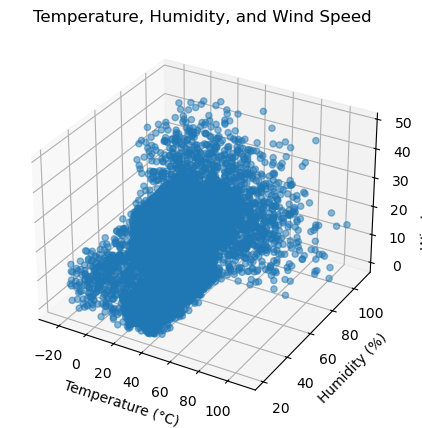

In [56]:
#Question 2: Create a 3D Scatter Plot of Temperature, Humidity, and Wind Speed. 
#You can use another library. Use Google for it. (Points 3)
# Create a scatter plot

# Place temperature, humidity, and wind speed on the three plot axes.
# Each point represents one row of the weather dataset.

fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(projection="3d")
ax.scatter(data['Temperature'], data['Humidity'], data['Wind Speed'], alpha = 0.5)

ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Humidity (%)")
ax.set_zlabel("Wind Speed (m/s)")
ax.set_title("Temperature, Humidity, and Wind Speed")

# Show plot
plt.show()

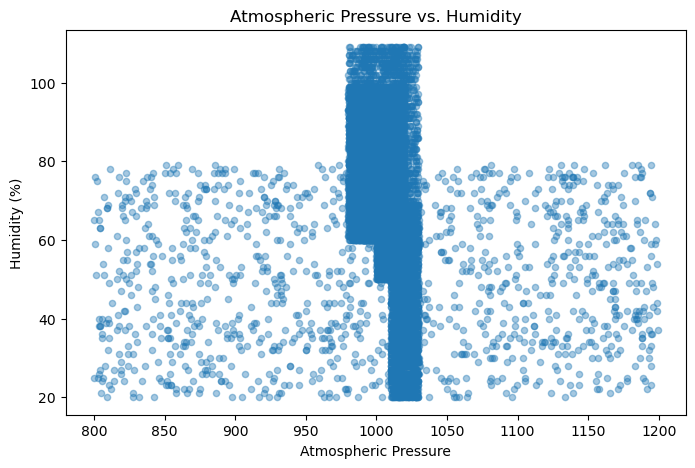

Correlation: -0.12065284945221189
There is a weak negative correlation.


In [57]:
#Question 3: Visually display the correlation between Atmospheric Pressure vs. Humidity. Comment on the correlation (Points 3)

# Plot each row to inspect the relationship between pressure and humidity.
# Print their correlation coefficient to summarize the direction and strength.

data.plot.scatter(
    x="Atmospheric Pressure",
    y="Humidity",
    alpha=0.4,
    figsize=(8, 5)
)

plt.title("Atmospheric Pressure vs. Humidity")
plt.xlabel("Atmospheric Pressure")
plt.ylabel("Humidity (%)")
plt.show()

print(
    "Correlation:",
    data["Atmospheric Pressure"].corr(data["Humidity"])
)

print("There is a weak negative correlation.")

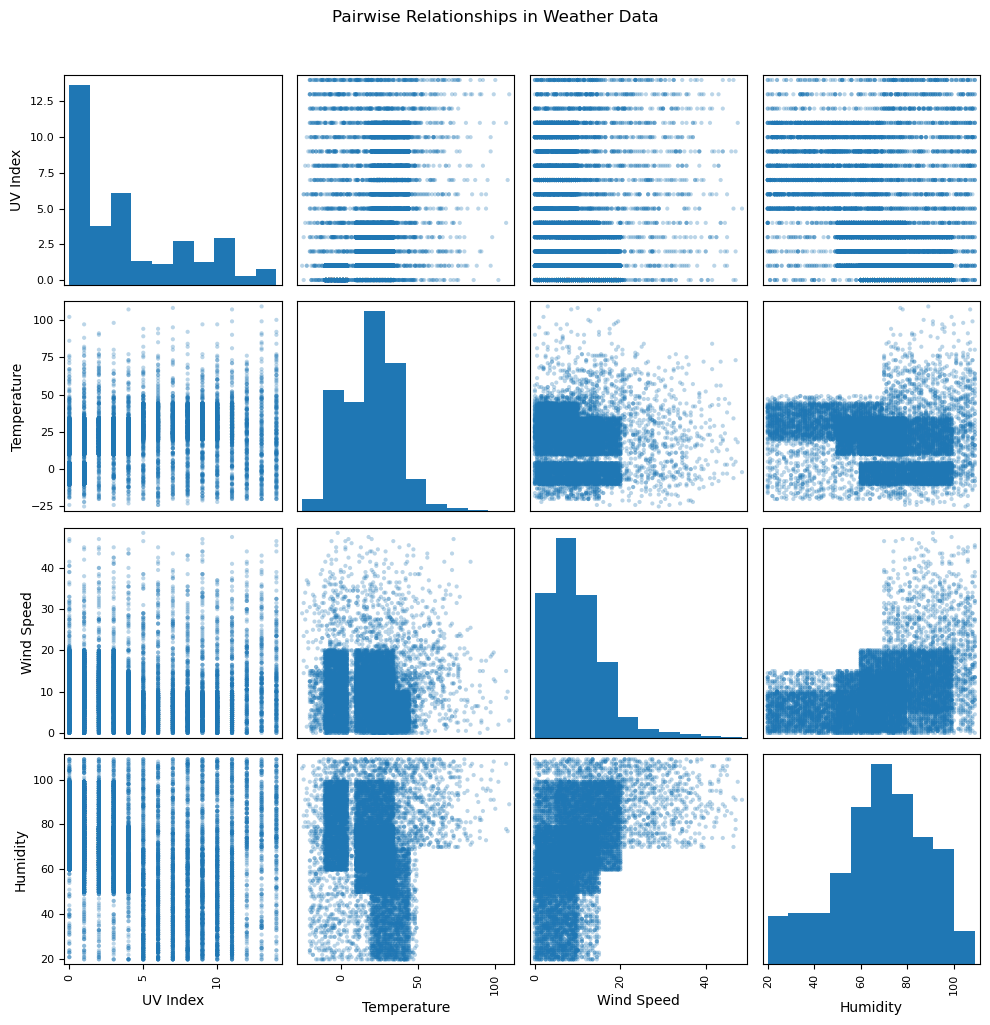

             UV Index  Temperature  Wind Speed  Humidity
UV Index         1.00         0.37       -0.07     -0.34
Temperature      0.37         1.00       -0.07     -0.21
Wind Speed      -0.07        -0.07        1.00      0.41
Humidity        -0.34        -0.21        0.41      1.00


In [58]:
#Question 4: You created a plot for two variables. Now, generate a pair-wise correlation plot for 
    #UV Index vs. Temperature vs. Wind Speed vs. Humidity. 
#It will be a grid-like system. I pasted the plot below for your reference. 
    #Feel free to reproduce it or develop your own (preferred). (Points 3)
from pandas.plotting import scatter_matrix

# Select only the four variables requested for pairwise comparisons.
# Draw a scatter plot for each pair and a histogram for each individual variable.

columns = ["UV Index", "Temperature", "Wind Speed", "Humidity"]

scatter_matrix(
    data[columns],
    figsize=(10, 10),
    diagonal="hist",
    alpha=0.3
)

plt.suptitle("Pairwise Relationships in Weather Data", y=1.02)
plt.tight_layout()
plt.show()

# Optional: print the correlation coefficients
print(data[columns].corr().round(2))

In [59]:
#Question 5: Generate the histogram of UV index. What do you think? Does it show normality? Can you make it close to normal?
#Hint: You may import the library math. (Points 3)

#Use this below library for any transformation
import math

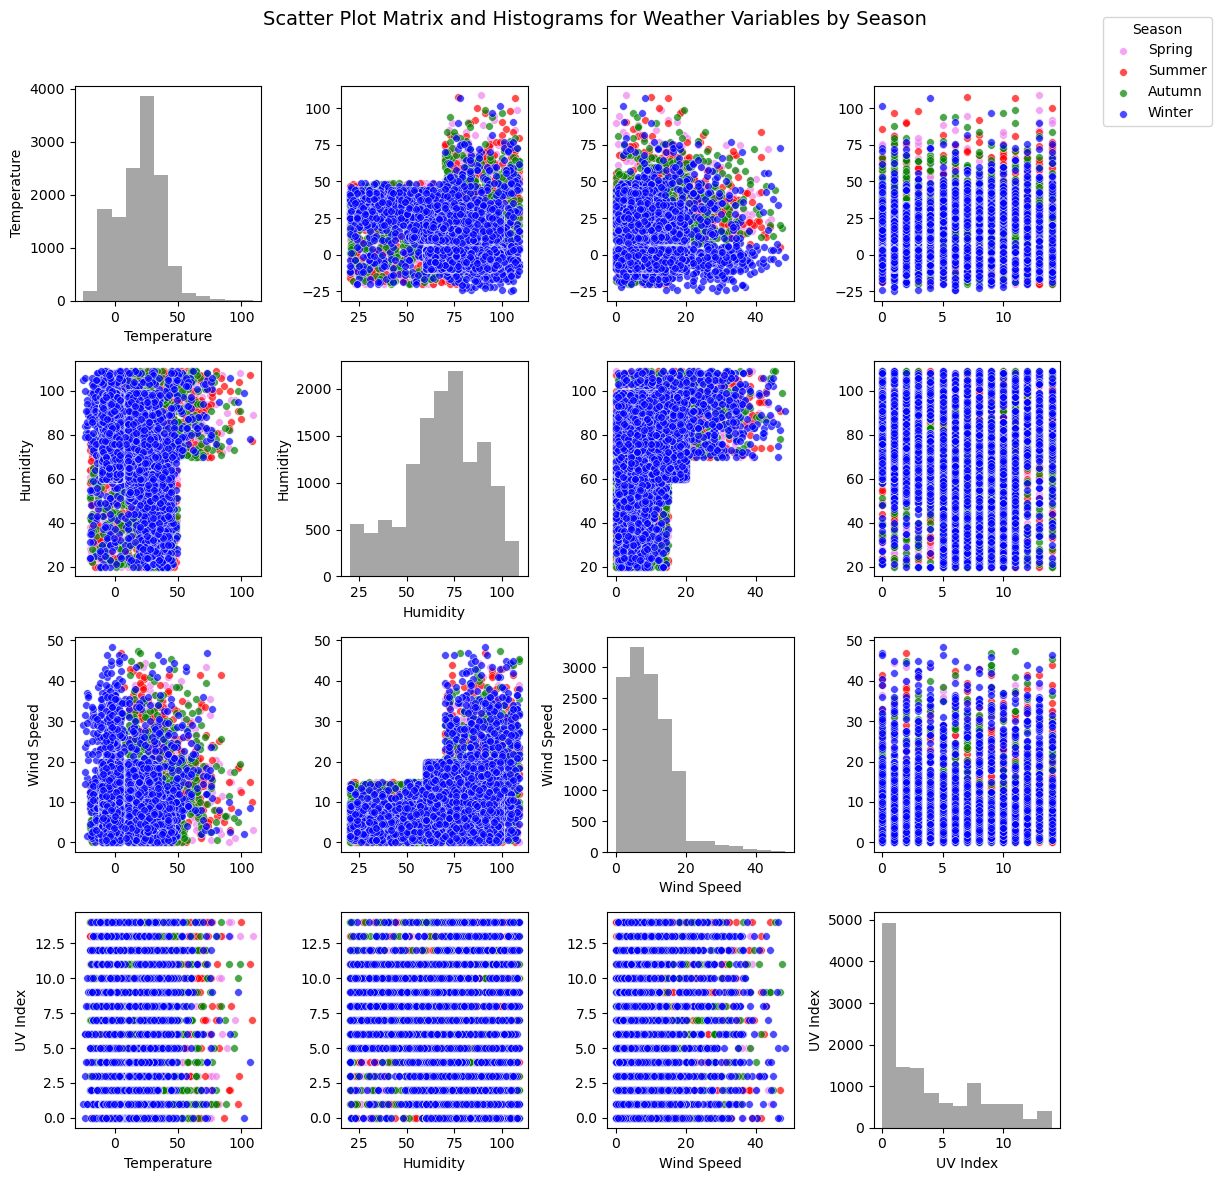

In [60]:
#Question 6 (Bonus): Can you reproduce the below plot? (Points 3)
variables = ["Temperature", "Humidity", "Wind Speed", "UV Index"]
seasons = ["Spring", "Summer", "Autumn", "Winter"]
colors = {
    "Spring": "violet",
    "Summer": "red",
    "Autumn": "green",
    "Winter": "blue",
}

# Build a four-by-four grid with a histogram when a variable is compared with itself.
# For every other pair, plot separate colored points for the four seasons.

bins = min(12, math.ceil(math.log2(len(data)) + 1))
fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for row, y_var in enumerate(variables):
    for col, x_var in enumerate(variables):
        ax = axes[row, col]

        if row == col:
            ax.hist(data[x_var].dropna(), bins=bins, color="0.65")
        else:
            for season in seasons:
                subset = data[data["Season"] == season]
                ax.scatter(
                    subset[x_var],
                    subset[y_var],
                    label=season,
                    color=colors[season],
                    s=30,
                    alpha=0.7,
                    edgecolors="white",
                    linewidths=0.4,
                )

        if row == 3 or row == col:
            ax.set_xlabel(x_var)
        if col == 0 or row == col:
            ax.set_ylabel(y_var)

# Take legend entries from one scatter subplot.
handles, labels = axes[0, 1].get_legend_handles_labels()
fig.legend(handles, labels, title="Season",
           loc="upper right", bbox_to_anchor=(1.02, 0.98))

fig.suptitle(
    "Scatter Plot Matrix and Histograms for Weather Variables by Season",
    fontsize=14
)
fig.tight_layout(rect=(0, 0, 0.9, 0.96))
plt.show()